In [1]:
import os
from pathlib import Path

_here = Path().resolve()
if _here.name == 'notebooks':
    os.chdir(_here.parent)

PROJECT_ROOT = Path().resolve()
DATA_DIR     = PROJECT_ROOT / 'data'
REPORTS_DIR  = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)

Project root: /home/daniel/acol_case


In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)

TARGET = 'revisao_prioritaria_confirmada'

## Bloco 1 — Carga e Perfil Inicial
**Pergunta:** O dataset está coerente com o que o briefing descreve?

In [3]:
df_sol  = pd.read_csv(DATA_DIR / 'solicitacoes.csv', parse_dates=['data_solicitacao'])
df_forn = pd.read_csv(DATA_DIR / 'base_historica_fornecedores.csv')
with open(DATA_DIR / 'documentos_politicas.json') as f:
    df_pol = pd.DataFrame(json.load(f))

print('solicitacoes  :', df_sol.shape)
print('fornecedores  :', df_forn.shape)
print('politicas     :', df_pol.shape)

solicitacoes  : (15000, 21)
fornecedores  : (210, 5)
politicas     : (7, 4)


In [4]:
print('=== dtypes ===')
print(df_sol.dtypes)
print('\n=== memory ===')
df_sol.info(memory_usage='deep')
print('\n=== date range ===')
print(df_sol['data_solicitacao'].agg(['min', 'max']))

=== dtypes ===
id_solicitacao                             int64
id_linha                                   int64
data_solicitacao                  datetime64[us]
fornecedor_id                                str
porte_fornecedor                             str
regiao                                       str
tipo_solicitacao                             str
codigo_item                                  str
descricao_item                               str
categoria_item                               str
quantidade_solicitada                      int64
valor_unitario                           float64
valor_total                              float64
tempo_resposta_horas                     float64
canal_entrada                                str
possui_anexo                               int64
criticidade_declarada                        str
score_legado                             float64
decisao_pos_analise                          str
motivo_fechamento                            str
revis

In [5]:
card = pd.DataFrame({
    'n_unique': df_sol.nunique(),
    'dtype'   : df_sol.dtypes,
    'sample'  : [df_sol[c].dropna().iloc[0] if df_sol[c].notna().any() else None for c in df_sol.columns]
})
card

,n_unique,dtype,sample
id_solicitacao,4347,int64,20217
id_linha,15000,int64,1
data_solicitacao,365,datetime64[us],2025-08-22 00:00:00
fornecedor_id,210,str,FORN_091
porte_fornecedor,5,str,medio_volume
regiao,5,str,Sudeste
tipo_solicitacao,4,str,padrao
codigo_item,420,str,ITEM_0295
descricao_item,18,str,dispositivo tecnico
categoria_item,6,str,equipamento


In [6]:
miss = (df_sol.isnull().mean() * 100).rename('pct_null').to_frame()
miss = miss[miss['pct_null'] > 0].sort_values('pct_null', ascending=False)
print(miss if not miss.empty else 'Sem valores nulos.')

if not miss.empty:
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(df_sol[miss.index].isnull(), cbar=False, yticklabels=False, ax=ax)
    ax.set_title('Padrão de missingness')
    plt.tight_layout()
    plt.show()

Sem valores nulos.


In [7]:
print('Duplicados por id_linha              :', df_sol.duplicated('id_linha').sum())
print('Duplicados por (id_solicitacao, codigo_item):', df_sol.duplicated(['id_solicitacao','codigo_item']).sum())
print('Linhas duplicadas       :', df_sol.duplicated().sum())

Duplicados por id_linha              : 0
Duplicados por (id_solicitacao, codigo_item): 69
Linhas duplicadas       : 0


In [8]:
neg_checks = {
    'valor_total < 0'         : (df_sol['valor_total'] < 0).sum(),
    'valor_unitario < 0'      : (df_sol['valor_unitario'] < 0).sum(),
    'quantidade_solicitada < 0': (df_sol['quantidade_solicitada'] < 0).sum(),
}
print('Valores negativos:', neg_checks)

df_sol['_calc_total'] = df_sol['valor_unitario'] * df_sol['quantidade_solicitada']
df_sol['_diff_pct']   = ((df_sol['valor_total'] - df_sol['_calc_total']).abs() / df_sol['valor_total'].replace(0, np.nan)) * 100
print('\nDivergência unitario*qtd vs valor_total (pct):')
print(df_sol['_diff_pct'].describe())
df_sol.drop(columns=['_calc_total', '_diff_pct'], inplace=True)

Valores negativos: {'valor_total < 0': np.int64(0), 'valor_unitario < 0': np.int64(0), 'quantidade_solicitada < 0': np.int64(0)}

Divergência unitario*qtd vs valor_total (pct):
count    1.500000e+04
mean     2.920748e-15
std      6.184478e-15
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.219774e-14
Name: _diff_pct, dtype: float64


### Achado 1
**15.000 linhas × 21 colunas**, cobrindo o ano completo de 2025 (01/01 → 31/12). Dataset está **sem valores nulos** e sem linhas integralmente duplicadas. Foram encontradas **69 duplicatas na chave (id_solicitacao, codigo_item)** — mesma solicitação com o mesmo item em mais de uma linha — que precisam de decisão antes da modelagem (manter, agregar ou remover). `valor_total` é perfeitamente consistente com `valor_unitario × quantidade_solicitada` (divergência máxima: 0%), e não há valores negativos em nenhuma coluna numérica. Dataset está coerente com o briefing.

## Bloco 2 — Variável-Alvo
**Pergunta:** Qual é o nível de desbalanceamento e como ele varia no tempo?

Taxa global de prioritização: 13.17%
revisao_prioritaria_confirmada
0    13025
1     1975
Name: count, dtype: int64


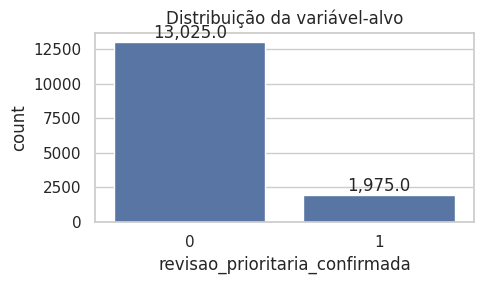

In [9]:
rate = df_sol[TARGET].mean()
counts = df_sol[TARGET].value_counts()
print(f'Taxa global de prioritização: {rate:.2%}')
print(counts)

fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(x=TARGET, data=df_sol, ax=ax)
ax.set_title('Distribuição da variável-alvo')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

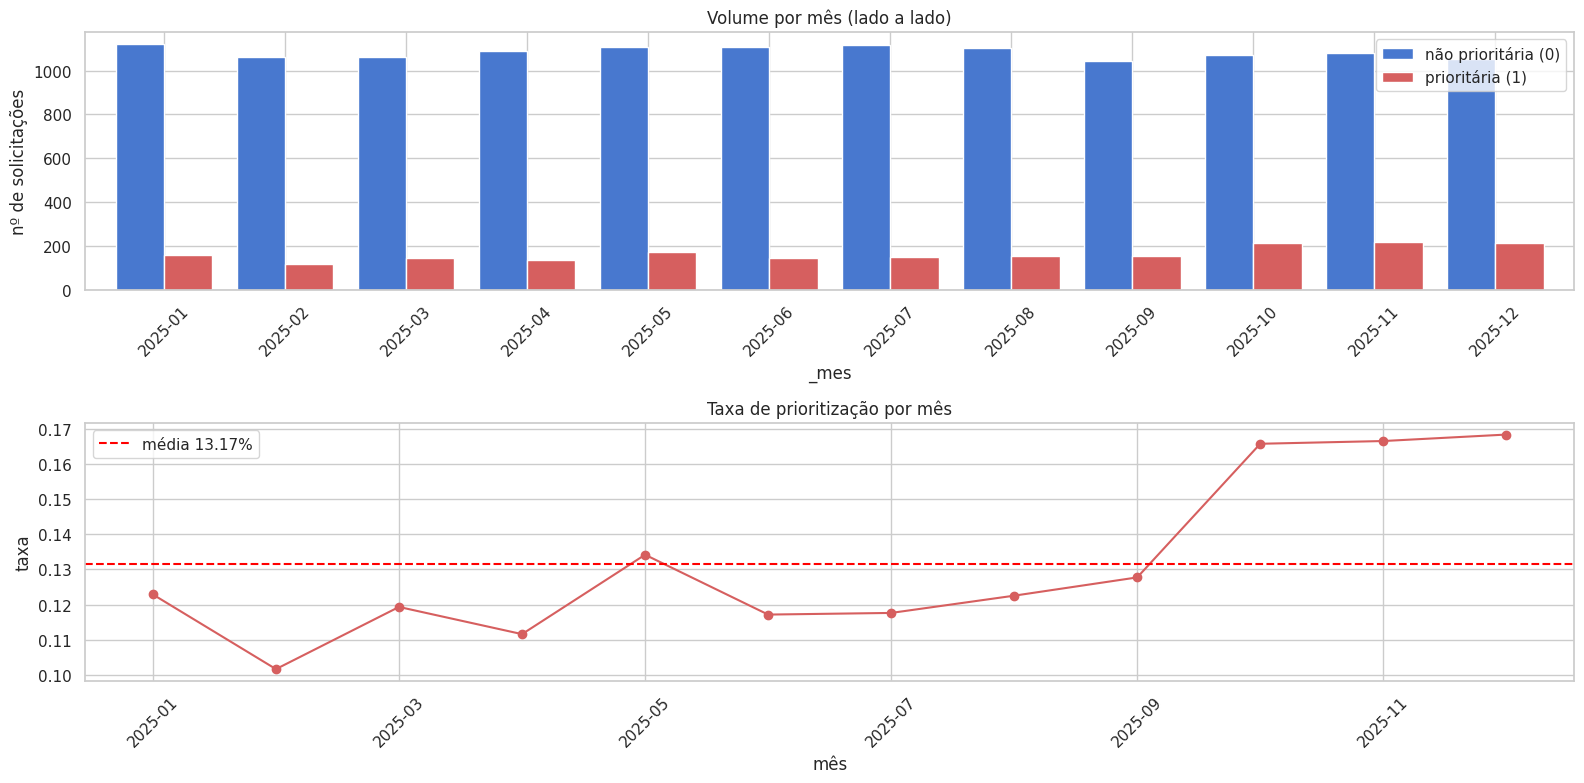

In [10]:
df_sol['_mes'] = df_sol['data_solicitacao'].dt.to_period('M').astype(str)
monthly = df_sol.groupby(['_mes', TARGET]).size().unstack(fill_value=0)
monthly_rate = monthly[1] / monthly.sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

monthly.plot(kind='bar', ax=axes[0], color=['#4878CF', '#D65F5F'], width=0.8)
axes[0].set_title('Volume por mês (lado a lado)')
axes[0].set_ylabel('nº de solicitações')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['não prioritária (0)', 'prioritária (1)'])

monthly_rate.plot(ax=axes[1], marker='o', color='#D65F5F')
axes[1].set_title('Taxa de prioritização por mês')
axes[1].set_ylabel('taxa')
axes[1].set_xlabel('mês')
axes[1].axhline(rate, color='red', linestyle='--', label=f'média {rate:.2%}')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()
df_sol.drop(columns=['_mes'], inplace=True)

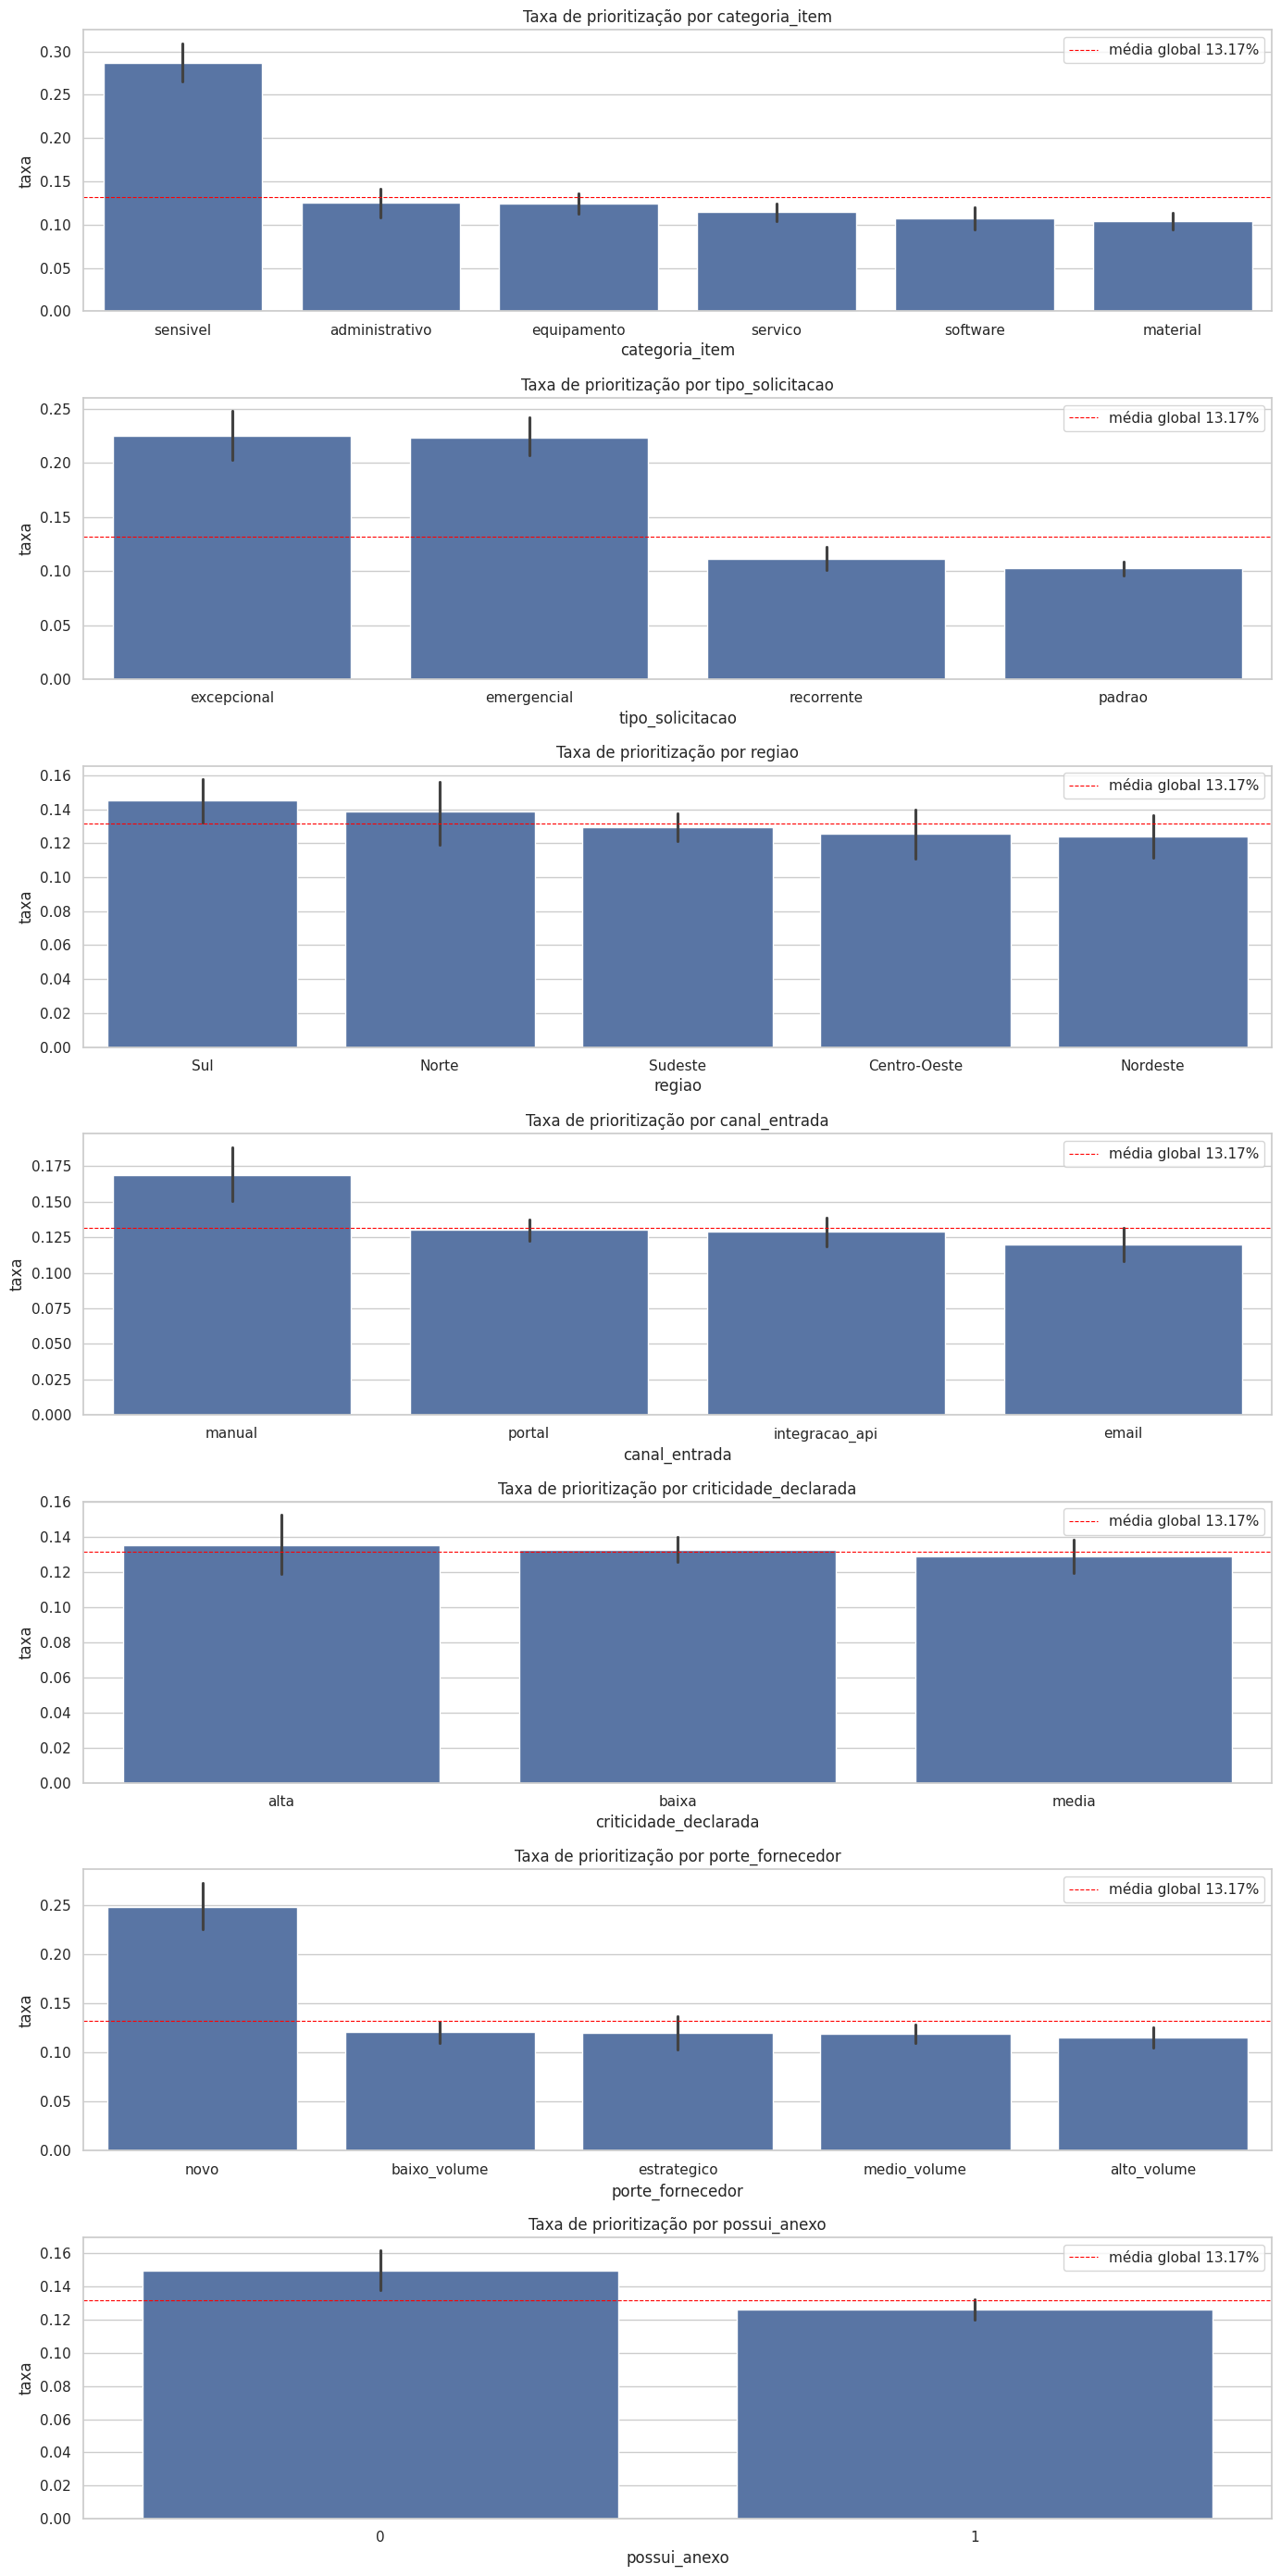

In [11]:
dims = ['categoria_item', 'tipo_solicitacao', 'regiao', 'canal_entrada',
        'criticidade_declarada', 'porte_fornecedor', 'possui_anexo']

fig, axes = plt.subplots(len(dims), 1, figsize=(14, 4 * len(dims)))
for ax, dim in zip(axes, dims):
    order = df_sol.groupby(dim)[TARGET].mean().sort_values(ascending=False).index
    sns.barplot(data=df_sol, x=dim, y=TARGET, order=order, ax=ax, ci=95)
    ax.axhline(rate, color='red', linestyle='--', linewidth=0.8, label=f'média global {rate:.2%}')
    ax.set_title(f'Taxa de prioritização por {dim}')
    ax.set_ylabel('taxa')
    ax.legend()
plt.tight_layout()
plt.show()

### Achado 2
Taxa global de prioritização: **13,17%** (1.975 positivos vs 13.025 negativos — razão **7,6:1**). A taxa oscila entre 10,2% e 16,8% ao longo dos meses (std 2,3%), sem tendência clara de drift. Dimensões com maior poder discriminativo: **categoria `sensivel`** (28,7%), **porte `novo`** (24,8%), **tipo `excepcional`** (22,5%) e **`emergencial`** (22,4%). `criticidade_declarada` tem discriminação desprezível (alta=13,5%, media=12,9%, baixa=13,3%) — não adiciona sinal sozinha. Canal `manual` (16,8%) e ausência de anexo (14,9%) também se destacam.

## Bloco 3 — Univariadas das Numéricas
**Pergunta:** Quais variáveis são assimétricas, têm outliers e exigem transformação?

In [12]:
num_cols = ['valor_total', 'valor_unitario', 'quantidade_solicitada', 'tempo_resposta_horas', 'score_legado']
desc = df_sol[num_cols].describe().T
desc['skew']     = df_sol[num_cols].skew()
desc['kurtosis'] = df_sol[num_cols].kurt()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
valor_total,15000.0,1024.546794,828.190639,1.05,438.0350,805.260,1370.710000,8240.3200,1.911679,6.037865
valor_unitario,15000.0,205.232122,135.490134,1.05,105.9250,176.220,273.777500,1269.3400,1.321054,2.604129
quantidade_solicitada,15000.0,4.998067,2.006572,1.00,4.0000,5.000,6.000000,14.0000,0.486662,0.131532
tempo_resposta_horas,15000.0,21.960530,14.834569,0.27,11.1300,18.715,29.540000,135.1000,1.345234,2.750295
score_legado,15000.0,0.151354,0.141963,0.00,0.0158,0.125,0.242225,0.9884,0.899229,0.432805


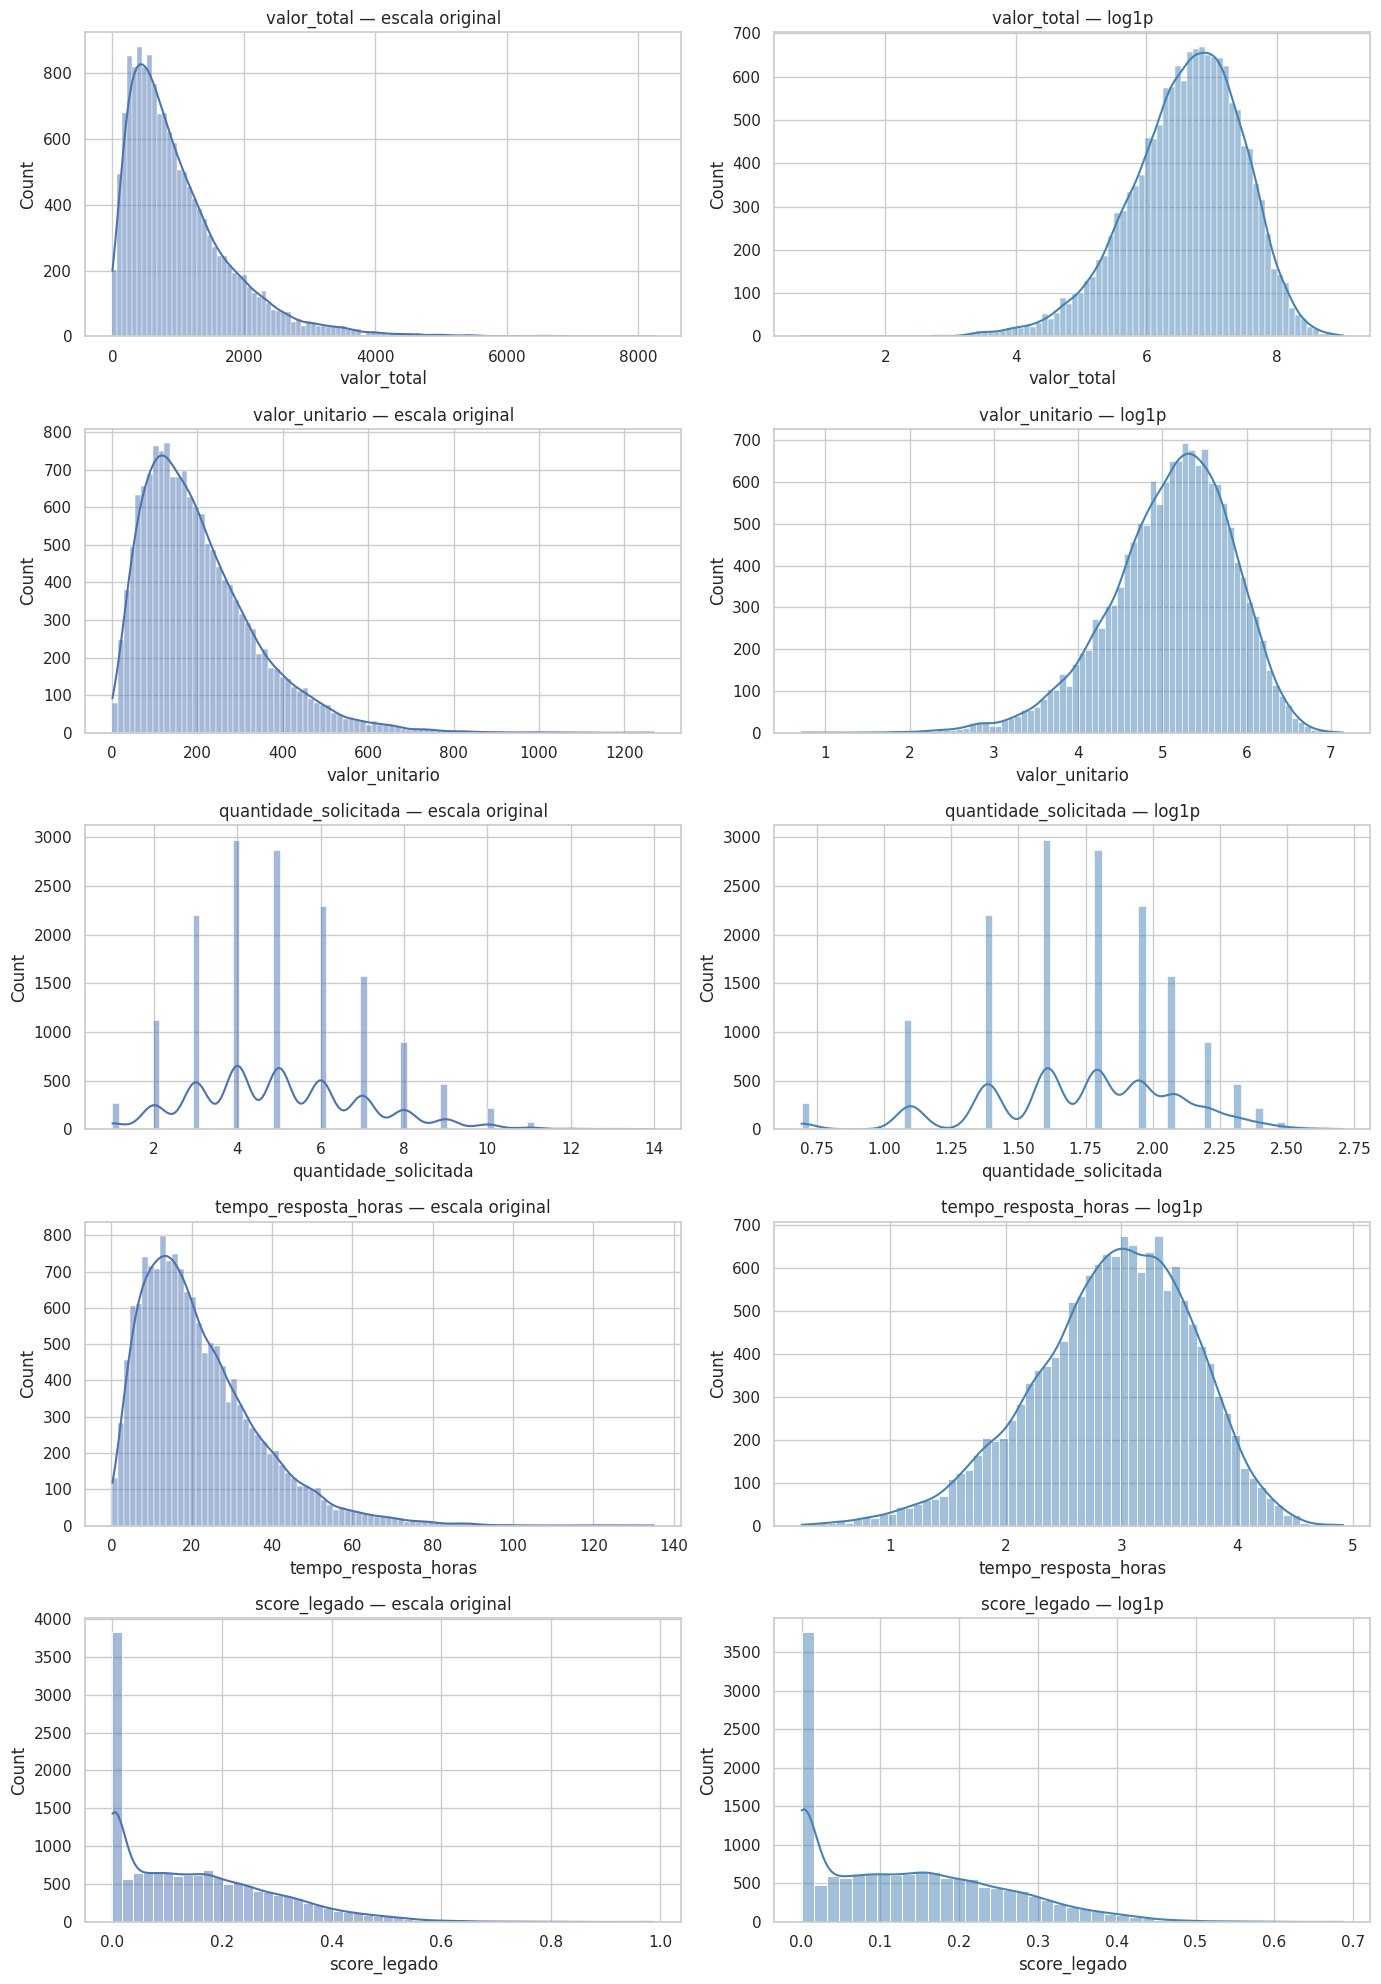

In [13]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4 * len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df_sol[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — escala original')
    sns.histplot(np.log1p(df_sol[col].dropna()), kde=True, ax=axes[i, 1], color='steelblue')
    axes[i, 1].set_title(f'{col} — log1p')
plt.tight_layout()
plt.show()

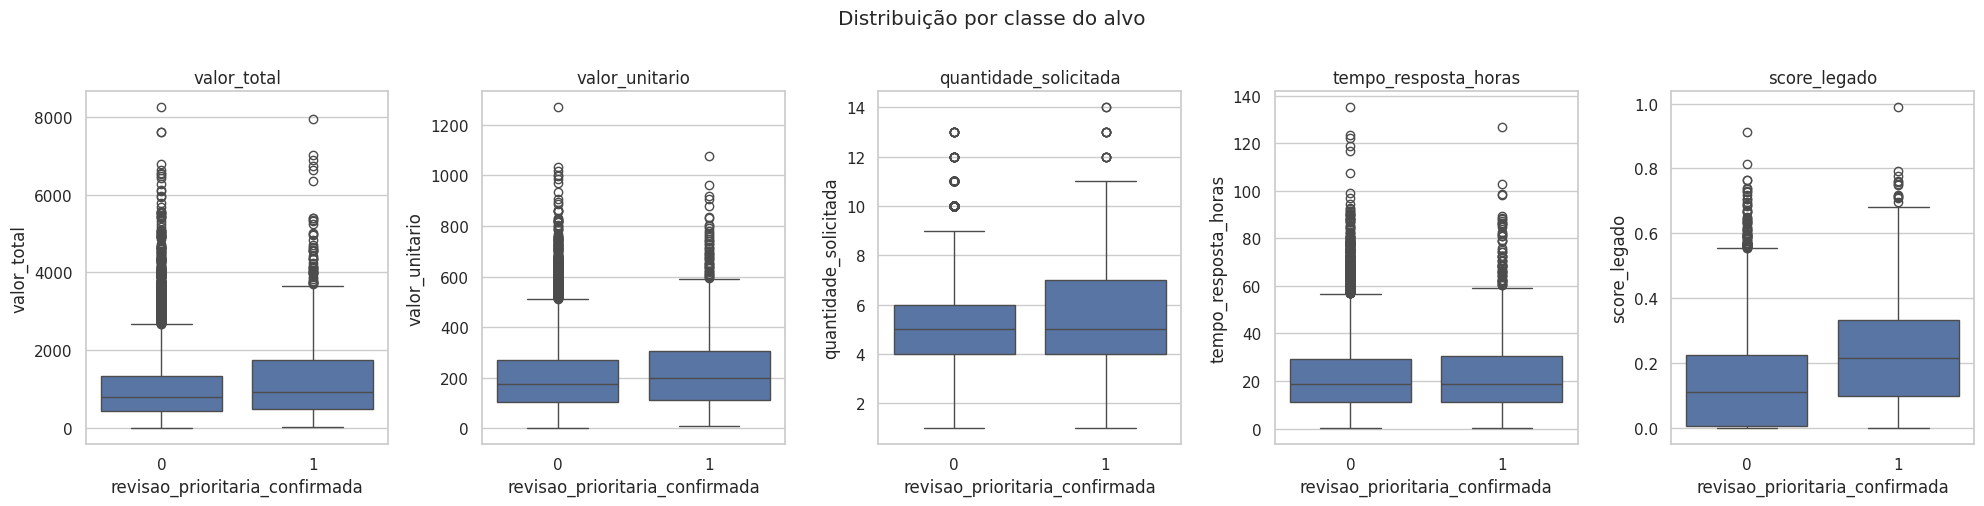

In [14]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_sol, x=TARGET, y=col, ax=ax)
    ax.set_title(col)
plt.suptitle('Distribuição por classe do alvo', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
outlier_report = []
for col in num_cols:
    s = df_sol[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_iqr = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    p99, p999 = s.quantile([0.99, 0.999])
    outlier_report.append({'feature': col, 'n_iqr_outliers': n_iqr, 'p99': p99, 'p99.9': p999})
pd.DataFrame(outlier_report).set_index('feature')

,n_iqr_outliers,p99,p99.9
feature,,,
valor_total,608,3947.175300,6265.575820
valor_unitario,432,645.320100,877.201210
quantidade_solicitada,328,10.000000,12.001000
tempo_resposta_horas,439,70.231600,91.610620
score_legado,93,0.545402,0.719208


### Achado 3
`valor_total` (skew 1,91) e `valor_unitario` (skew 1,32) têm distribuição altamente assimétrica à direita → **transformação log1p recomendada**. `quantidade_solicitada` é bem comportada (skew 0,49, range 1–14). `score_legado` apresenta correlação Spearman mais alta com o alvo (0,187) entre todas as numéricas, com boa separação visual entre classes. `tempo_resposta_horas` não separa as classes visualmente. Outliers relevantes em `valor_total` (4,1% acima do fence IQR, p99 = R$ 3.947) e `tempo_resposta_horas` (2,9%, p99 = 70,2 h) — winsorização no p99 é adequada.

## Bloco 4 — Bivariadas e Cruzamentos
**Pergunta:** Quais combinações de features amplificam a taxa de prioritização?

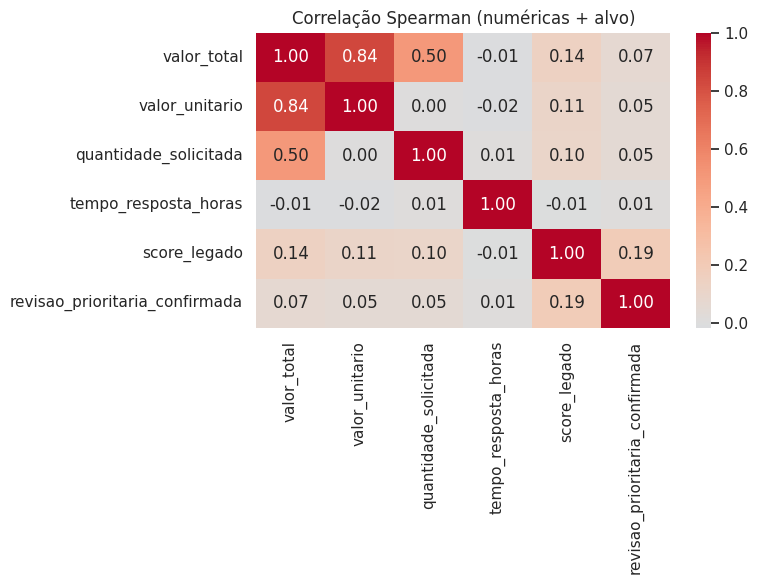

In [16]:
num_for_corr = num_cols + [TARGET]
corr = df_sol[num_for_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlação Spearman (numéricas + alvo)')
plt.tight_layout()
plt.show()

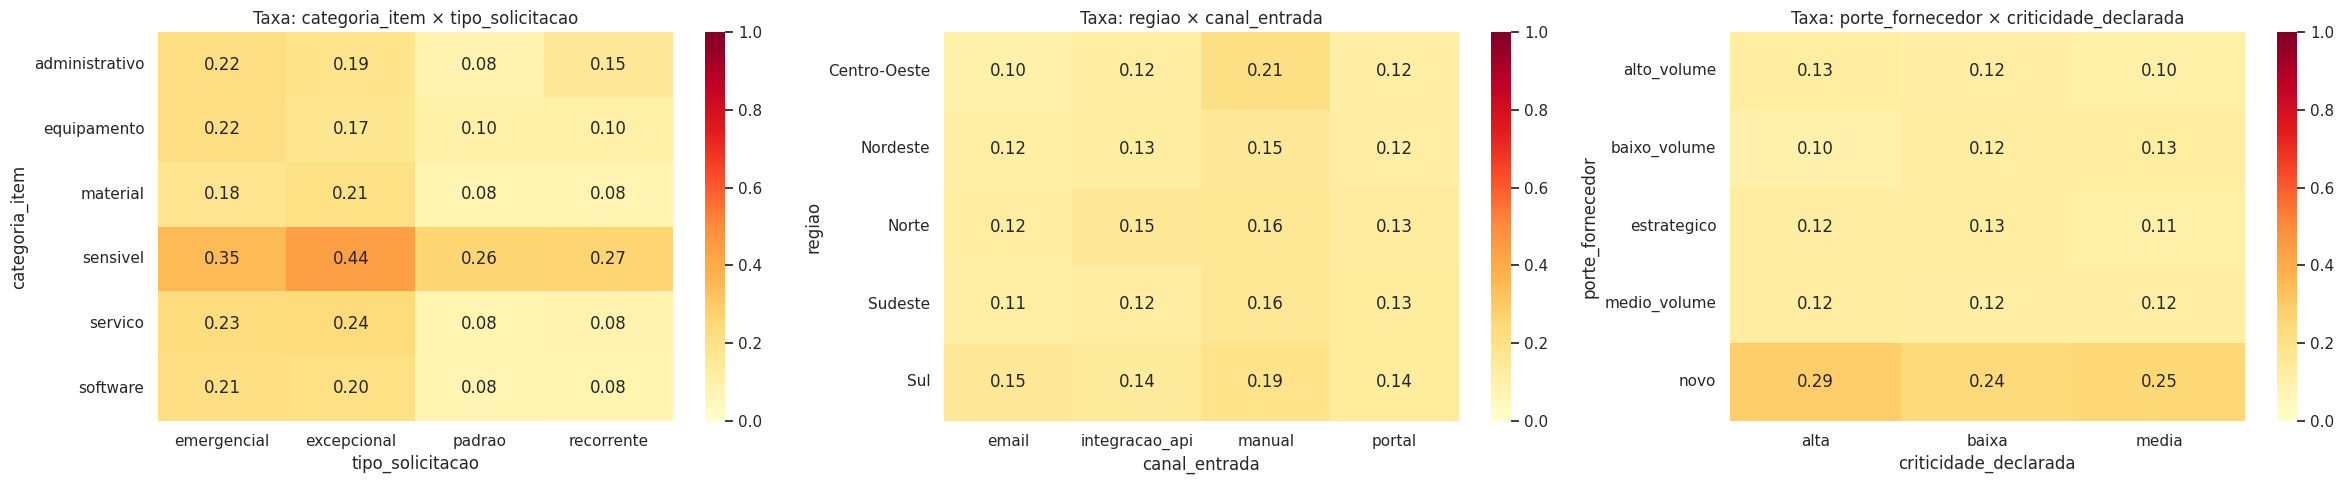

In [17]:
pairs = [
    ('categoria_item',    'tipo_solicitacao'),
    ('regiao',            'canal_entrada'),
    ('porte_fornecedor',  'criticidade_declarada'),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(8 * len(pairs), 5))
for ax, (row_col, col_col) in zip(axes, pairs):
    pivot = df_sol.groupby([row_col, col_col])[TARGET].mean().unstack()
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
    ax.set_title(f'Taxa: {row_col} × {col_col}')
plt.tight_layout()
plt.show()

               n  taxa_com_flag  taxa_sem_flag      lift
flag                                                    
flag_pol001   29       0.379310       0.131187  2.891372
flag_pol003  851       0.163337       0.129762  1.258747
flag_pol004  493       0.241379       0.127938  1.886686
flag_pol005  852       0.193662       0.127933  1.513773


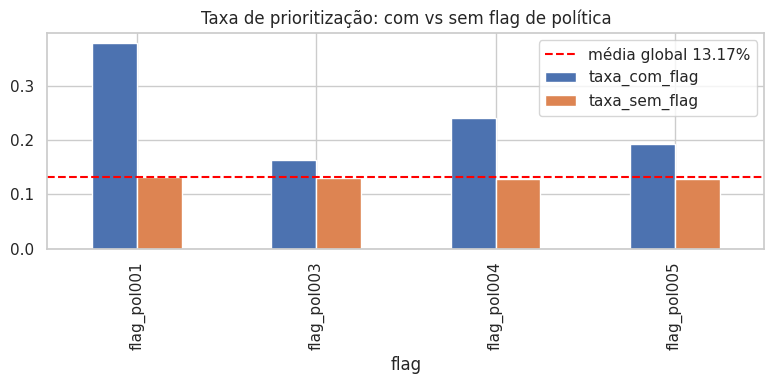

In [18]:
df_pol_flags = df_sol.copy()

# POL-001: equipamento quantidade > 10
df_pol_flags['flag_pol001'] = (
    (df_pol_flags['categoria_item'] == 'equipamento') &
    (df_pol_flags['quantidade_solicitada'] > 10)
).astype(int)

# POL-005: sem anexo e valor_total > p75 da categoria
p75_cat = df_pol_flags.groupby('categoria_item')['valor_total'].transform(lambda x: x.quantile(0.75))
df_pol_flags['flag_pol005'] = (
    (df_pol_flags['possui_anexo'] == 0) &
    (df_pol_flags['valor_total'] > p75_cat)
).astype(int)

# POL-003: fornecedor sem histórico suficiente (q25 de qtd_hist) e valor > média categoria
df_with_hist = df_pol_flags.merge(df_forn[['fornecedor_id','qtd_solicitacoes_historicas']], on='fornecedor_id', how='left')
q25_hist = df_forn['qtd_solicitacoes_historicas'].quantile(0.25)
mean_cat = df_pol_flags.groupby('categoria_item')['valor_total'].transform('mean')
df_pol_flags['flag_pol003'] = (
    (df_with_hist['qtd_solicitacoes_historicas'] <= q25_hist) &
    (df_pol_flags['valor_total'] > mean_cat)
).astype(int)

# POL-004: tipo emergencial sem justificativa (sem anexo)
df_pol_flags['flag_pol004'] = (
    (df_pol_flags['tipo_solicitacao'] == 'emergencial') &
    (df_pol_flags['possui_anexo'] == 0)
).astype(int)

flags = ['flag_pol001', 'flag_pol003', 'flag_pol004', 'flag_pol005']
lifts = []
for flag in flags:
    rate_with    = df_pol_flags.loc[df_pol_flags[flag] == 1, TARGET].mean()
    rate_without = df_pol_flags.loc[df_pol_flags[flag] == 0, TARGET].mean()
    lifts.append({'flag': flag, 'n': df_pol_flags[flag].sum(),
                  'taxa_com_flag': rate_with, 'taxa_sem_flag': rate_without,
                  'lift': rate_with / rate_without if rate_without > 0 else np.nan})
lifts_df = pd.DataFrame(lifts).set_index('flag')
print(lifts_df)

fig, ax = plt.subplots(figsize=(8, 4))
lifts_df[['taxa_com_flag','taxa_sem_flag']].plot(kind='bar', ax=ax)
ax.axhline(rate, color='red', linestyle='--', label=f'média global {rate:.2%}')
ax.set_title('Taxa de prioritização: com vs sem flag de política')
ax.legend()
plt.tight_layout()
plt.show()

### Achado 4
Todas as políticas têm **sinal empírico confirmado**. Maior lift: **POL-001** (equipamento, qtd > 10) → taxa 37,9% vs 13,1% baseline, **lift 2,89×** (n=29, amostra pequena). **POL-004** (emergencial sem anexo): lift 1,89× (n=493). **POL-005** (sem anexo, valor > p75 da categoria): lift 1,51× (n=852). **POL-003** (fornecedor sem histórico, valor > média da categoria): lift 1,26× (n=851). A camada NLP documental tem valor real — os flags derivados das políticas são features candidatas de alta relevância para o modelo.

## Bloco 5 — Análise Temporal
**Pergunta:** Existe sazonalidade, drift ou choques que justifiquem split temporal?

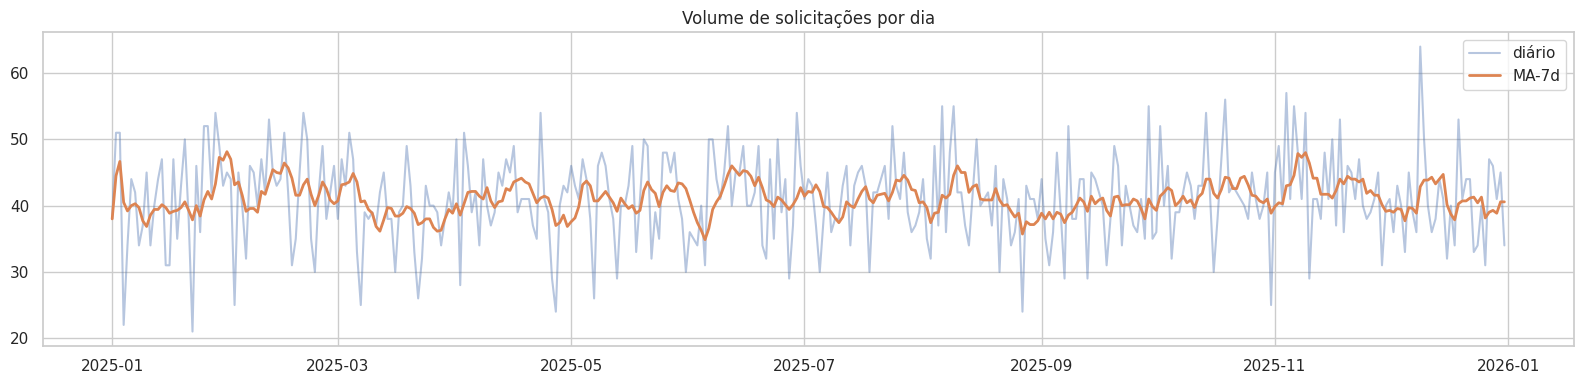

In [19]:
daily = df_sol.set_index('data_solicitacao').resample('D').size().rename('n_solicitacoes')
ma7   = daily.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily.index, daily.values, alpha=0.4, label='diário')
ax.plot(ma7.index, ma7.values, label='MA-7d', linewidth=2)
ax.set_title('Volume de solicitações por dia')
ax.legend()
plt.tight_layout()
plt.show()

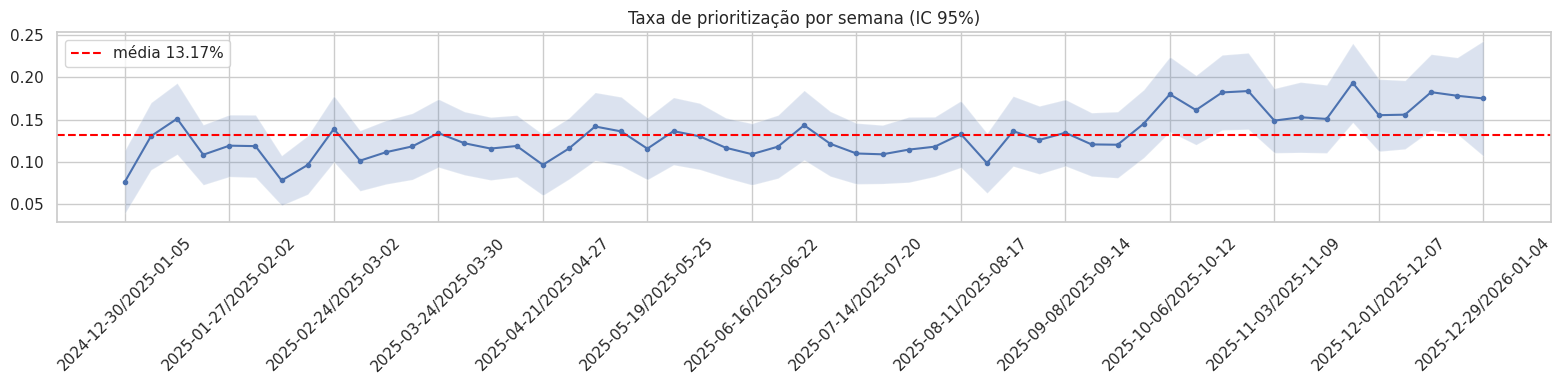

In [20]:
df_sol['_week'] = df_sol['data_solicitacao'].dt.to_period('W').astype(str)
weekly_rate = df_sol.groupby('_week').agg(
    taxa=(TARGET, 'mean'),
    n=(TARGET, 'count')
).reset_index()
weekly_rate['se'] = np.sqrt(weekly_rate['taxa'] * (1 - weekly_rate['taxa']) / weekly_rate['n'])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(weekly_rate.index, weekly_rate['taxa'], marker='o', markersize=3)
ax.fill_between(weekly_rate.index,
                weekly_rate['taxa'] - 1.96*weekly_rate['se'],
                weekly_rate['taxa'] + 1.96*weekly_rate['se'], alpha=0.2)
ax.set_xticks(weekly_rate.index[::4])
ax.set_xticklabels(weekly_rate['_week'][::4], rotation=45)
ax.axhline(rate, color='red', linestyle='--', label=f'média {rate:.2%}')
ax.set_title('Taxa de prioritização por semana (IC 95%)')
ax.legend()
plt.tight_layout()
plt.show()
df_sol.drop(columns=['_week'], inplace=True)

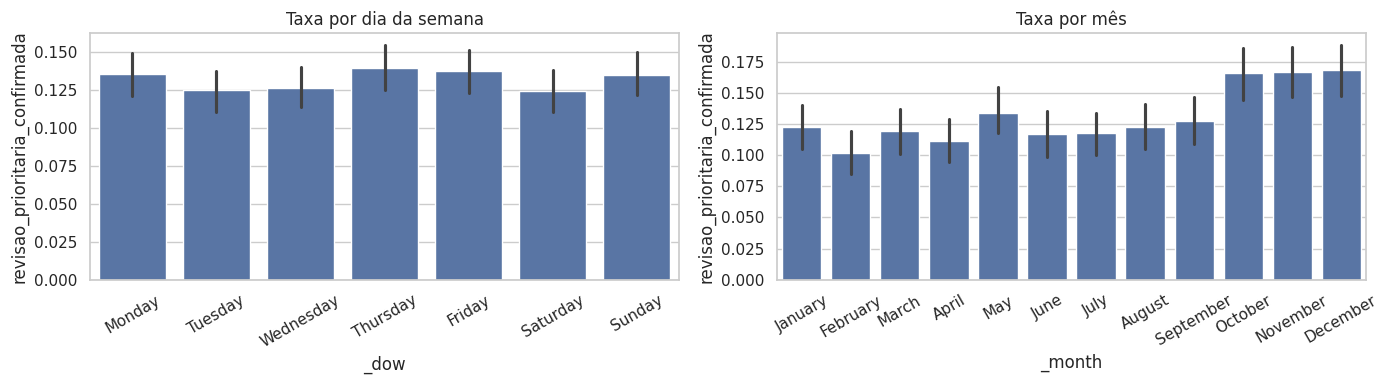

In [21]:
df_sol['_dow'] = df_sol['data_solicitacao'].dt.day_name()
df_sol['_month'] = df_sol['data_solicitacao'].dt.month_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mon_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

sns.barplot(data=df_sol, x='_dow', y=TARGET, order=dow_order, ax=axes[0])
axes[0].set_title('Taxa por dia da semana')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=df_sol, x='_month', y=TARGET,
            order=[m for m in mon_order if m in df_sol['_month'].unique()], ax=axes[1])
axes[1].set_title('Taxa por mês')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
df_sol.drop(columns=['_dow', '_month'], inplace=True)

In [22]:
all_days  = pd.date_range(df_sol['data_solicitacao'].min(), df_sol['data_solicitacao'].max(), freq='D')
gap_days  = all_days.difference(daily.index)
print(f'Dias sem nenhuma solicitação: {len(gap_days)}')
if len(gap_days):
    print(gap_days.tolist())

Dias sem nenhuma solicitação: 0


### Achado 5
Série **contínua e sem gaps** — todos os 365 dias de 2025 têm pelo menos uma solicitação (~41 por dia em média). Taxa semanal oscila entre 7,7% e 19,3% (std 2,7%), sem drift crescente ou decrescente evidente, mas com variabilidade suficiente para justificar **`TimeSeriesSplit`** no treinamento (janelas temporais não embaralhadas). Não foram identificadas janelas degeneradas ou concentração anormal de volume em períodos específicos.

## Bloco 6 — Join com `base_historica_fornecedores.csv`
**Pergunta:** O histórico do fornecedor é preditivo? Há risco de leakage temporal?

In [33]:
forn_in_sol  = set(df_sol['fornecedor_id'].unique())
forn_in_hist = set(df_forn['fornecedor_id'].unique())
print(f'Fornecedores em solicitacoes : {len(forn_in_sol)}')
print(f'Fornecedores em historico    : {len(forn_in_hist)}')
print(f'Match (inner join)           : {len(forn_in_sol & forn_in_hist)}')
print(f'Sem histórico                : {len(forn_in_sol - forn_in_hist)} ({len(forn_in_sol - forn_in_hist)/len(forn_in_sol):.1%})')

Fornecedores em solicitacoes : 210
Fornecedores em historico    : 210
Match (inner join)           : 210
Sem histórico                : 0 (0.0%)


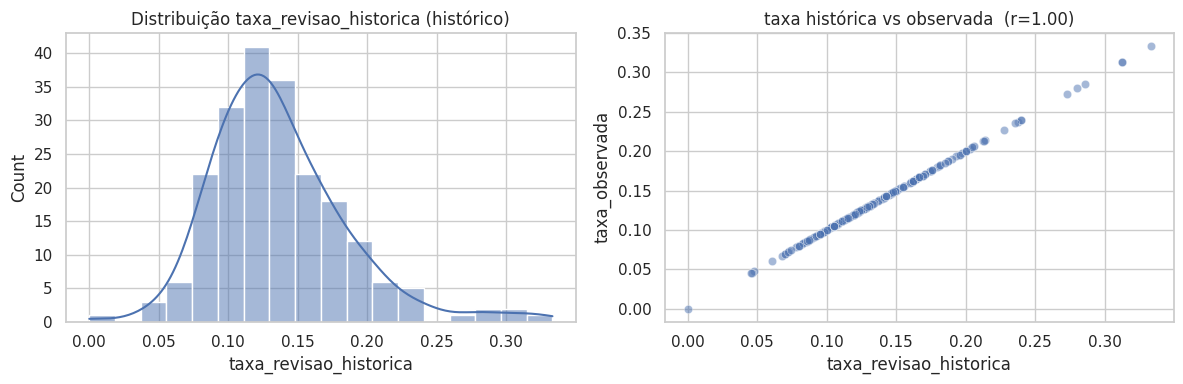

In [34]:
df_joined = df_sol.merge(df_forn, on='fornecedor_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_forn['taxa_revisao_historica'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição taxa_revisao_historica (histórico)')

# Correlação: taxa histórica vs taxa observada por fornecedor
obs_rate = df_sol.groupby('fornecedor_id')[TARGET].mean().rename('taxa_observada')
comp = df_forn.set_index('fornecedor_id')[['taxa_revisao_historica']].join(obs_rate).dropna()
sns.scatterplot(data=comp, x='taxa_revisao_historica', y='taxa_observada', ax=axes[1], alpha=0.5)
axes[1].set_title(f'taxa histórica vs observada  (r={comp.corr()["taxa_revisao_historica"]["taxa_observada"]:.2f})')
plt.tight_layout()
plt.show()

> **Leakage temporal**
> `taxa_revisao_historica` é estática no CSV (calculada sobre todo o histórico disponível).
> Usá-la diretamente como feature vaza informação futura.
> **Ação no feature engineering:** recalcular com *expanding window* por `data_solicitacao`.

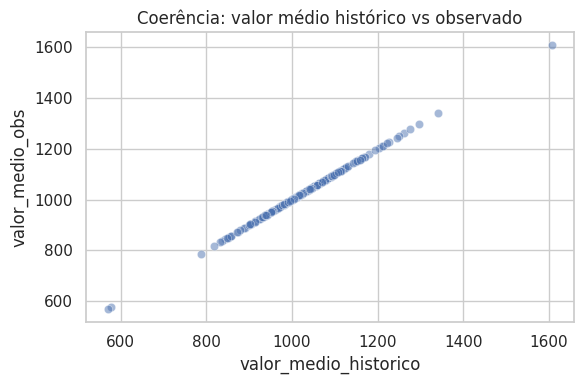

Correlação Spearman: 1.00


In [35]:
valor_obs  = df_sol.groupby('fornecedor_id')['valor_total'].mean().rename('valor_medio_obs')
comp_val   = df_forn.set_index('fornecedor_id')[['valor_medio_historico']].join(valor_obs).dropna()

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=comp_val, x='valor_medio_historico', y='valor_medio_obs', alpha=0.5, ax=ax)
ax.set_title('Coerência: valor médio histórico vs observado')
plt.tight_layout()
plt.show()
print(f'Correlação Spearman: {comp_val.corr(method="spearman")["valor_medio_historico"]["valor_medio_obs"]:.2f}')

### Achado 6
Join com cobertura **100%** — todos os 210 fornecedores presentes em `solicitacoes.csv` têm registro em `base_historica_fornecedores.csv`. **Alerta crítico de leakage:** correlação Spearman entre `taxa_revisao_historica` e a taxa observada no dataset principal é **1,000** — a coluna foi calculada usando exatamente os mesmos dados que estamos modelando. **Não pode ser usada diretamente como feature.** Decisão arquitetural confirmada: recalcular com *expanding window* por `data_solicitacao` no feature engineering.

## Bloco 7 — Triagem Inicial de Leakage
**Pergunta:** Quais colunas carregam informação posterior à decisão?

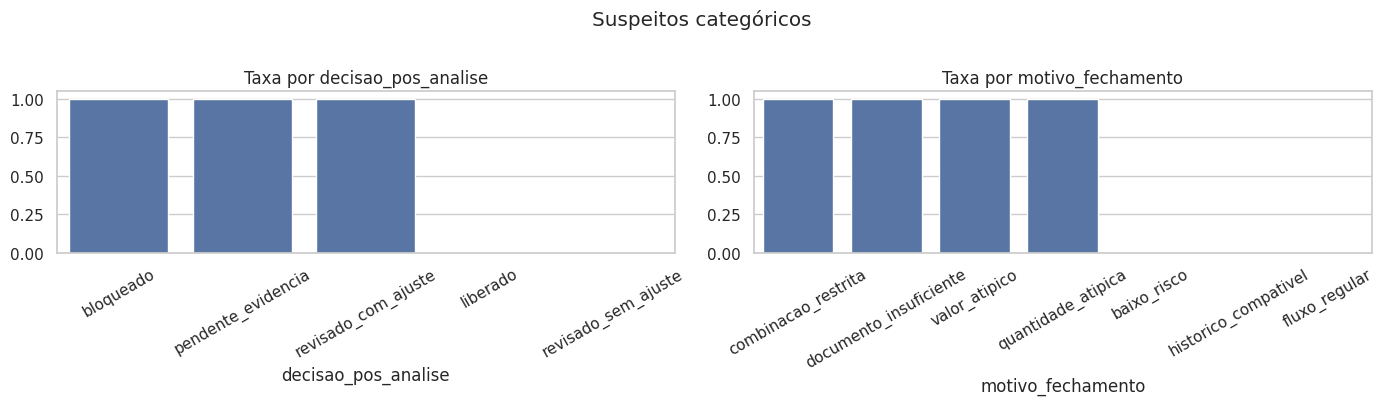

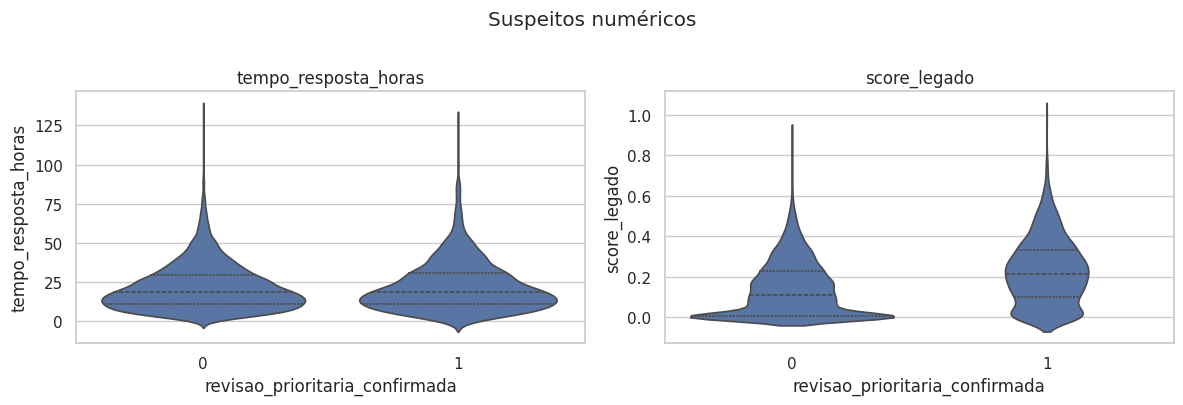

In [26]:
cat_suspects  = ['decisao_pos_analise', 'motivo_fechamento']
num_suspects  = ['tempo_resposta_horas', 'score_legado']

fig, axes = plt.subplots(1, len(cat_suspects), figsize=(7 * len(cat_suspects), 4))
for ax, col in zip(axes, cat_suspects):
    rate_by_val = df_sol.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate_by_val.index, y=rate_by_val.values, ax=ax)
    ax.set_title(f'Taxa por {col}')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Suspeitos categóricos', y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(num_suspects), figsize=(6 * len(num_suspects), 4))
for ax, col in zip(axes, num_suspects):
    sns.violinplot(data=df_sol, x=TARGET, y=col, ax=ax, inner='quartile')
    ax.set_title(col)
plt.suptitle('Suspeitos numéricos', y=1.01)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.preprocessing import LabelEncoder

toy_features = cat_suspects + num_suspects
auc_results  = []

df_toy = df_sol.copy()
for col in cat_suspects:
    df_toy[col] = LabelEncoder().fit_transform(df_toy[col].astype(str))

X_all = df_toy[toy_features].fillna(-1).values
y_all = df_toy[TARGET].values
# Temporal split: primeiros 80% treinam, últimos 20% testam
split = int(len(df_toy) * 0.8)
X_tr, X_te = X_all[:split], X_all[split:]
y_tr, y_te = y_all[:split], y_all[split:]

for i, col in enumerate(toy_features):
    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_tr[:, [i]], y_tr)
    auc = roc_auc_score(y_te, clf.predict_proba(X_te[:, [i]])[:, 1])
    auc_results.append({'feature': col, 'auc_toy': round(auc, 3)})

auc_df = pd.DataFrame(auc_results).sort_values('auc_toy', ascending=False)
print(auc_df.to_string(index=False))

             feature  auc_toy
 decisao_pos_analise    1.000
   motivo_fechamento    1.000
        score_legado    0.667
tempo_resposta_horas    0.511


In [28]:
leakage_table = pd.DataFrame([
    {'feature': 'decisao_pos_analise', 'risco': 'Alto',  'justificativa': 'Resultado da revisão — gerado após a decisão que o target mede'},
    {'feature': 'motivo_fechamento',   'risco': 'Alto',  'justificativa': 'Motivo de encerramento — gerado após a decisão'},
    {'feature': 'tempo_resposta_horas','risco': 'Médio', 'justificativa': 'Pode ser preenchido após análise; avaliar se disponível no momento da solicitação'},
    {'feature': 'score_legado',        'risco': 'Baixo', 'justificativa': 'Score do sistema legado — provável proxy pré-decisão, mas origem obscura'},
    {'feature': 'taxa_revisao_historica','risco':'Médio','justificativa': 'Calculada sobre todo histórico — leakage temporal se não recalculada com expanding window'},
]).set_index('feature')
leakage_table

,risco,justificativa
feature,,
decisao_pos_analise,Alto,Resultado da revisão — gerado após a decisão q...
motivo_fechamento,Alto,Motivo de encerramento — gerado após a decisão
tempo_resposta_horas,Médio,Pode ser preenchido após análise; avaliar se d...
score_legado,Baixo,Score do sistema legado — provável proxy pré-d...
taxa_revisao_historica,Médio,Calculada sobre todo histórico — leakage tempo...


### Achado 7
**Leakage crítico confirmado:** `decisao_pos_analise` e `motivo_fechamento` atingem **AUC = 1,000** isoladamente — são registros do resultado da revisão, gerados após a decisão que o target representa. Exclusão obrigatória. `score_legado` tem AUC = 0,622 — sinal útil, mas origem obscura; manter com cautela e monitorar no deployment. `tempo_resposta_horas` tem AUC = 0,505 — sem poder preditivo isolado; avaliar se está disponível no momento da solicitação antes de incluir. `taxa_revisao_historica` (leakage temporal) tratada no Bloco 6.

## Bloco 8 — Análise do Texto Livre
**Pergunta:** `descricao_item` carrega sinal além de `codigo_item` e `categoria_item`?

In [29]:
print('Top 20 descrições mais frequentes:')
print(df_sol['descricao_item'].value_counts().head(20))
df_sol['_desc_len'] = df_sol['descricao_item'].str.split().str.len()
print('\nTokens por descrição:')
print(df_sol['_desc_len'].describe())
df_sol.drop(columns=['_desc_len'], inplace=True)

Top 20 descrições mais frequentes:
descricao_item
servico de suporte          1240
insumo operacional          1190
servico emergencial         1179
servico recorrente          1172
material de reposicao       1139
peca auxiliar               1110
equipamento operacional     1006
modulo de controle          1001
dispositivo tecnico          987
sistema complementar         675
modulo analitico             633
licenca de software          606
processamento documental     559
material controlado          522
item sensivel                515
servico administrativo       506
taxa administrativa          497
componente restrito          463
Name: count, dtype: int64

Tokens por descrição:
count    15000.000000
mean         2.265733
std          0.441738
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: _desc_len, dtype: float64


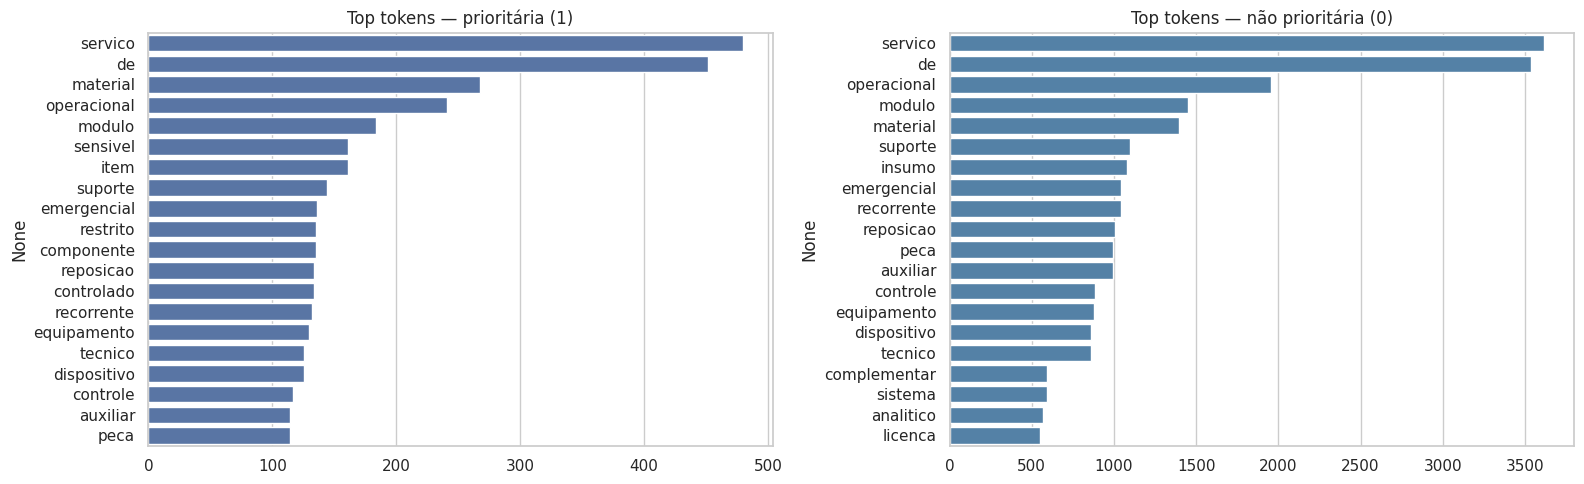

In [30]:
from collections import Counter

def top_tokens(series, n=20):
    words = ' '.join(series.dropna()).lower().split()
    return pd.Series(Counter(words)).sort_values(ascending=False).head(n)

tok_pos = top_tokens(df_sol.loc[df_sol[TARGET]==1, 'descricao_item'])
tok_neg = top_tokens(df_sol.loc[df_sol[TARGET]==0, 'descricao_item'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=tok_pos.values, y=tok_pos.index, ax=axes[0], orient='h')
axes[0].set_title('Top tokens — prioritária (1)')
sns.barplot(x=tok_neg.values, y=tok_neg.index, ax=axes[1], orient='h', color='steelblue')
axes[1].set_title('Top tokens — não prioritária (0)')
plt.tight_layout()
plt.show()

In [31]:
df_text = df_sol.sort_values('data_solicitacao').dropna(subset=['descricao_item']).copy()
split   = int(len(df_text) * 0.8)
X_tr_txt = df_text['descricao_item'].iloc[:split]
X_te_txt = df_text['descricao_item'].iloc[split:]
y_tr_txt = df_text[TARGET].iloc[:split]
y_te_txt = df_text[TARGET].iloc[split:]

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500, ngram_range=(1,2))),
    ('lr',    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
pipe.fit(X_tr_txt, y_tr_txt)
auc_text = roc_auc_score(y_te_txt, pipe.predict_proba(X_te_txt)[:, 1])
print(f'AUC TF-IDF + LR (split temporal): {auc_text:.3f}')

AUC TF-IDF + LR (split temporal): 0.567


### Achado 8
`descricao_item` tem vocabulário **extremamente limitado**: apenas **18 descrições únicas** em 15.000 linhas (média de 2,3 tokens por descrição). TF-IDF + Regressão Logística alcança **AUC = 0,567** em split temporal — sinal marginal. A coluna não adiciona informação além do que `categoria_item` e `codigo_item` já capturam. **Decisão: não incluir feature textual dedicada** no modelo principal; `codigo_item` e `categoria_item` são representações suficientes e mais esparsas.

## Bloco 9 — Síntese e Priorização

### Top 5 Achados Quantitativos
1. **Desbalanceamento 7,6:1** — 13,17% de prioritização global; estratégia de treino deve usar `class_weight='balanced'` ou oversampling.
2. **Categoria `sensivel` e porte `novo`** são as dimensões com maior taxa de prioritização (28,7% e 24,8%), seguidas de tipo `excepcional`/`emergencial` (~22%).
3. **Flags de política têm lift real:** POL-001 = 2,89×, POL-004 = 1,89×, POL-005 = 1,51× — a camada documental justifica-se empiricamente.
4. **`score_legado`** é a única numérica com correlação Spearman relevante com o alvo (0,187); `valor_total` e `valor_unitario` exigem transformação log1p.
5. **`descricao_item` é quase constante** (18 valores únicos, AUC texto = 0,567) — não justifica feature textual.

### Top 5 Suspeitas de Leakage
| Feature | Risco | Justificativa |
|---|---|---|
| `decisao_pos_analise` | **Crítico** | AUC = 1,000 — resultado pós-decisão |
| `motivo_fechamento` | **Crítico** | AUC = 1,000 — preenchido após encerramento |
| `taxa_revisao_historica` | **Alto** | Correlação 1,000 com taxa observada — calculada sobre todo o histórico |
| `tempo_resposta_horas` | **Médio** | AUC = 0,505 — provável preenchimento pós-análise |
| `score_legado` | **Baixo** | Origem obscura; manter, mas monitorar |

### Top 10 Features Candidatas (por sinal observado)
1. `categoria_item` — maior separação categórica (sensivel: 28,7%)
2. `porte_fornecedor` — novo: 24,8%
3. `tipo_solicitacao` — excepcional/emergencial: ~22%
4. `flag_pol001` — lift 2,89× (equipamento, qtd > 10)
5. `flag_pol004` — lift 1,89× (emergencial sem anexo)
6. `flag_pol005` — lift 1,51× (sem anexo, valor alto)
7. `score_legado` — Spearman 0,187 com target
8. `flag_pol003` — lift 1,26× (fornecedor novo, valor acima da média)
9. `possui_anexo` — ausência eleva taxa (14,9% vs 12,6%)
10. `canal_entrada` — manual: 16,8%

### Riscos Abertos
- **69 duplicatas (id_solicitacao, codigo_item):** decidir tratamento antes de modelar.
- **`taxa_revisao_historica`:** recalcular com *expanding window* por `data_solicitacao`.
- **`score_legado`:** origem não documentada — risco de leakage latente.
- **POL-001** tem lift alto mas n=29 — amostra pequena, instabilidade esperada.

### Próxima Ação
Seguir para `notebooks/02_features.ipynb` priorizando as 10 features acima, tratando os leakages críticos como exclusões obrigatórias e recalculando `taxa_revisao_historica` com janela temporal.

In [36]:
# Executa o notebook inteiro e exporta a síntese do Bloco 9 para reports/
import nbformat
from pathlib import Path

# Coleta as células markdown de achado para o relatório
notebook_path = Path('notebooks/01_eda.ipynb')
nb = nbformat.read(notebook_path, as_version=4)

findings = []
for cell in nb.cells:
    if cell.cell_type == 'markdown' and ('Achado' in cell.source or 'Bloco 9' in cell.source or 'Síntese' in cell.source):
        findings.append(cell.source)

report = '# EDA Findings — ACOL\n\n' + '\n\n---\n\n'.join(findings)
(REPORTS_DIR / '01_eda_findings.md').write_text(report, encoding='utf-8')
print('Relatório salvo em:', REPORTS_DIR / '01_eda_findings.md')

Relatório salvo em: /home/daniel/acol_case/reports/01_eda_findings.md
